In [1]:
# =====================================================
# ARGOS Alpha 0.1.0 - Exploratory Data Analysis (EDA)
# Dataset: MaestroMiscelaneos.parquet
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Configuración general ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# --- Cargar dataset ---
file_path = Path("../data/external/MaestroMiscelaneos.parquet")

if not file_path.exists():
    raise FileNotFoundError("No se encontró el archivo MaestroMiscelaneos.parquet en data/external/")

df = pd.read_parquet(file_path)

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df.head()

Dataset cargado: 43812 filas x 7 columnas



,Código (Value),Descripción Breve,Descripcion Larga,UM,Grupo,Jerarquia,tipo_material
0,10098296,"UNION 1/4'''', SWAGELOK COMPANY","UNION 1/4"" - 1/4""_SS-400-6_UNION 1/4"" TUBE O.D...",PZA,ACCTUBERI,PARE_ACCE_ACOPLE,UNION
1,10099245,"4 HOLES SLIP-ON FLANGE 2"".","FLANGE 4 HOLES, SLIP ON 150# WN/SO RF/FF FS AS...",PZA,ACCTUBERI,PARE_ACCE_BRIDA,BRIDA
2,10099542,A2 STNL ST HEX FULL (DESCONTINUADO),"TUERCA HEXAGONAL MILIMETRICA , ACERO INOXIDABL...",PAQ,TORNILLOS,OPER_CONS_TORNILLE,TUERCA
3,10099961,ADJUSTABLE ELBOW 12MM THREAD S,ELBOW 12.0MM ADJUSTABLE SERIES S _ PARKER EO.9...,PZA,ACCTUBERI,OPER_ACCE_INSHIDRA,CODO
4,10099991,ADJUSTABLE RUN TEE12MM-12MM-12MM-SERIE-L,TEE 12MM ADJUSTABLE RUN SERIES L _ USA EQUIVAL...,PZA,ACCTUBERI,OPER_ACCE_INSHIDRA,TEE


## Análisis inicial

Sección 1 — Resumen general

In [2]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43812 entries, 0 to 43811
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Código (Value)     43812 non-null  object
 1   Descripción Breve  43812 non-null  object
 2   Descripcion Larga  43812 non-null  object
 3   UM                 43812 non-null  object
 4   Grupo              43812 non-null  object
 5   Jerarquia          43812 non-null  object
 6   tipo_material      43812 non-null  object
dtypes: object(7)
memory usage: 2.3+ MB


,count,unique,top,freq
Código (Value),43812,43812,10098296,1
Descripción Breve,43812,35040,CODIGO BLOQUEADO - NO CARGADO A MDG,387
Descripcion Larga,43812,39922,"PERFIL, DE ACERO AL CARBON, SIN RECUBRIMIENTO,...",5
UM,43812,14,PZA,37703
Grupo,43812,30,RESGUARDO,12742
Jerarquia,43812,276,,12768
tipo_material,43812,24,VALVULA,7817


Sección 2 — Nulos y duplicados

In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())

print("\nDuplicados:", df.duplicated().sum())

Valores nulos por columna:
Código (Value)       0
Descripción Breve    0
Descripcion Larga    0
UM                   0
Grupo                0
Jerarquia            0
tipo_material        0
dtype: int64

Duplicados: 0


Sección 3 — Frecuencias básicas

In [4]:
for col in df.columns[:5]:  # ajusta según columnas
    print(f"\nColumna: {col}")
    print(df[col].value_counts(dropna=False).head(10))


Columna: Código (Value)
Código (Value)
10098296    1
10099245    1
10099542    1
10099961    1
10099991    1
10101375    1
10101387    1
10101394    1
10101396    1
10101397    1
Name: count, dtype: int64

Columna: Descripción Breve
Descripción Breve
CODIGO BLOQUEADO - NO CARGADO A MDG         387
ESPARRAGO, DE ACERO AL CARBON, CON RECUB     75
ESPARRAGO, DE ACERO AL CARBONO, CON RECU     43
EMPAQUE ACERO INOXIDABLE TIPO 316 DEVANA     34
TUBO, DE ACERO AL CARBON, SIN RECUBRIMIE     26
EMPAQUE, ESPIROMETALICO, ACERO INOXIDABL     24
REDUCCION CONCENTRICA TIPO SWAGE, ACERO      23
WELDOLET, ACERO AL CARBON FORJADO, ESPEC     21
REDUCCION, DE ACERO AL CARBON, SIN RECUB     19
BRIDA FORJADA DE ACERO AL CARBON, TIPO S     19
Name: count, dtype: int64

Columna: Descripcion Larga
Descripcion Larga
PERFIL, DE ACERO AL CARBON, SIN RECUBRIMIENTO, TIPO: I RECTANGULAR (IR), 6" X 4.016" X 0.260" DE ESPESOR, 24.000 KG/M, ESPECIFICACION: ASTM: A572, GRADO: 50.                                       

Sección 4 — Limpieza mínima

In [5]:
# Ejemplo: limpiar espacios o mayúsculas en descripciones
if "Descripcion Larga" in df.columns:
    df["Descripcion Larga"] = df["Descripcion Larga"].astype(str).str.strip().str.upper()

4.1 — Check ejemplo

In [6]:
df["Descripcion Larga"].head()

0    UNION 1/4" - 1/4"_SS-400-6_UNION 1/4" TUBE O.D...
1    FLANGE 4 HOLES, SLIP ON 150# WN/SO RF/FF FS AS...
2    TUERCA HEXAGONAL MILIMETRICA , ACERO INOXIDABL...
3    ELBOW 12.0MM ADJUSTABLE SERIES S _ PARKER EO.9...
4    TEE 12MM ADJUSTABLE RUN SERIES L _ USA EQUIVAL...
Name: Descripcion Larga, dtype: object

Sección 5 — Visualización básica

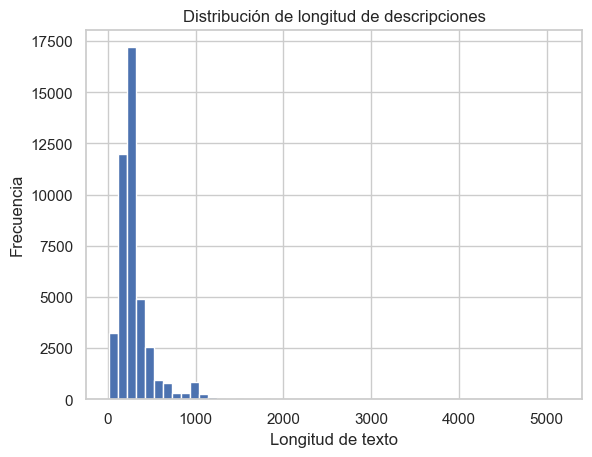

In [7]:
sns.set(style="whitegrid")

# Distribución de longitud de descripciones (útil para NLP)
if "Descripcion Larga" in df.columns:
    df["desc_len"] = df["Descripcion Larga"].str.len()
    plt.hist(df["desc_len"], bins=50)
    plt.title("Distribución de longitud de descripciones")
    plt.xlabel("Longitud de texto")
    plt.ylabel("Frecuencia")
    plt.show()

Sección 6 — Guardar resumen limpio

In [8]:
output_path = Path("../data/processed/EDA_resumen.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)  # <-- crea el directorio si no existe
df.describe(include='all').to_csv(output_path)
print(f"Resumen guardado en {output_path}")

Resumen guardado en ..\data\processed\EDA_resumen.csv


## Analisis de clases y tipo de material